# MABSTRUCT GAMESTUDIO STUDY SHEET

implementing game studio via LangGraph study

## MABSTRUCT GAMESTUDIO CONCEPT

PRODUCER --> IDEATION --> DESIGN --> DEVELOP <--> TEST --> DEPLOYMENT


In [1]:
# Imports and environment first, as always

import os
import operator
import random
import requests
import uuid
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from typing import List

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.agents import create_agent



load_dotenv(override=True)

True

In [2]:
from langsmith import utils

utils.get_env_var.cache_clear()  # clear stale notebook cache

print("tracing:", utils.get_env_var("TRACING") or utils.get_env_var("TRACING_V2"))
print("project:", utils.get_env_var("PROJECT"))
print("endpoint:", utils.get_env_var("ENDPOINT"))
print("api key set:", bool(utils.get_env_var("API_KEY")))

tracing: true
project: GAMESTUDIO-STUDY
endpoint: https://eu.api.smith.langchain.com
api key set: True


In [3]:
# Getting the Telegram bot token and chat ID from environment variables
# You can also replace these with your actual values directly

TELEGRAM_BOT_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN", "your_bot_token_here")
TELEGRAM_CHAT_ID = os.getenv("TELEGRAM_CHAT_ID", "your_chat_id_here")

### verify TELEGRAM token and chat_id are there

if TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID:
    print("TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found")
else:
    print("TELEGRAM_BOT_TOKEN or TELEGRAM_CHAT_ID not found")



TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found


In [4]:
def send_telegram_message(text):
    url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
    payload = {"chat_id": TELEGRAM_CHAT_ID, "text": text}
    response = requests.post(url, data=payload)

    if response.status_code == 200:
        # print("Message sent successfully!")
        return {"status": "success", "message": text}
    else:
        # print(f"Failed to send message. Status code: {response.status_code}")
        # print(response.text)
        return {"status": "error", "message": response.text}

## Adding tools


Adding Tavily Search.

Adding Telegram Push Tool.

In [7]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

search = TavilySearch(max_results=5)

@tool
def send_push_notification(text: str) -> str:
    """Send a short push notification to the user's phone."""
    send_telegram_message(text)
    return "Notification sent"

tools = [search, send_push_notification]
llm_with_tools = llm.bind_tools(tools)

## Models, configurations and middleware to use 


In [205]:
import httpx
import anthropic
import openai
from langchain_anthropic import ChatAnthropic
from langchain.agents.middleware import ModelRetryMiddleware
from langchain_anthropic.middleware import AnthropicPromptCachingMiddleware

LLM_IDEATION_MODEL = ChatOpenAI(model="gpt-5.6-sol", reasoning_effort="none")
LLM_DESIGN_MODEL = ChatOpenAI(model="gpt-5.6-terra", reasoning_effort="none")

# Develop needs many long tool steps (start + js chunks + end + verify).
# The string form "anthropic:claude-opus-5" resolves to max_tokens=4096, which truncates
# tool arguments mid-JSON; Opus 5 supports up to 128k and runs adaptive thinking by default.
LLM_DEVELOP_OPUS_MODEL = ChatAnthropic(
    model="claude-opus-5",
    max_tokens=32000,
    streaming=True,               # required at large max_tokens to avoid HTTP timeouts
    effort="medium",              # trims thinking spend for mechanical code emission
    default_request_timeout=300,  # per-read idle timeout: fail fast on a stalled stream
    max_retries=2,
)

LLM_DEVELOP_FABLE_MODEL = ChatAnthropic(
    model="claude-fable-5",
    max_tokens=32000,
    streaming=True,
    effort="medium",
    default_request_timeout=300,
    max_retries=2,
)

# Same setup on the OpenAI client. Parameter names differ from ChatAnthropic:
#   max_tokens               -> max_tokens (alias of max_completion_tokens)  same name
#   effort                   -> reasoning_effort
#   default_request_timeout  -> request_timeout (alias: timeout)
# gpt-5.6-sol rejects any reasoning_effort other than "none" when function tools are
# bound on /v1/chat/completions. Either keep "none" (below), or switch to the Responses
# API to get real reasoning:  use_responses_api=True, reasoning_effort="low".
LLM_DEVELOP_GPT_MODEL = ChatOpenAI(
    model="gpt-5.6-sol",
    max_tokens=32000,
    streaming=True,
    reasoning_effort="none",
    request_timeout=300,
    max_retries=2,
)

# Swap this line to pick the develop model under test.
LLM_DEVELOP_MODEL = LLM_DEVELOP_OPUS_MODEL

DEVELOP_RECURSION_LIMIT = 200

# Transport faults surface while the SSE body is being consumed, which is outside the
# SDK retry loop (it covers sending the request and receiving headers only).
# Retrying here re-issues one model call instead of losing the whole build.
DEVELOP_TRANSPORT_ERRORS = (
    httpx.RemoteProtocolError,
    httpx.ReadError,
    httpx.ReadTimeout,
    anthropic.APIConnectionError,  # APITimeoutError subclasses this
    anthropic.InternalServerError,
    anthropic.RateLimitError,
    openai.APIConnectionError,     # APITimeoutError subclasses this
    openai.InternalServerError,
    openai.RateLimitError,
)

DEVELOP_MIDDLEWARE = [
    ModelRetryMiddleware(
        max_retries=3,
        retry_on=DEVELOP_TRANSPORT_ERRORS,
        on_failure="error",  # raise, so develop_node can still salvage the file on disk
        initial_delay=2.0,
    ),
]

# Anthropic-only: caches system prompt, tool schemas and the conversation prefix.
# On a non-Anthropic model it warns on every turn and caches nothing, so only add it
# when it applies. OpenAI caches long prefixes server-side with no configuration.
if isinstance(LLM_DEVELOP_MODEL, ChatAnthropic):
    DEVELOP_MIDDLEWARE.append(AnthropicPromptCachingMiddleware())

_dev_model_id = getattr(LLM_DEVELOP_MODEL, "model", None) or getattr(LLM_DEVELOP_MODEL, "model_name", "?")
print(f"develop model: {type(LLM_DEVELOP_MODEL).__name__} {_dev_model_id} | "
      f"middleware: {[type(m).__name__ for m in DEVELOP_MIDDLEWARE]}")


develop model: ChatAnthropic claude-opus-5 | middleware: ['ModelRetryMiddleware', 'AnthropicPromptCachingMiddleware']


## Ideation Agent

### A simple agent

In [190]:
GAME_TITLE = "The Big Swallow"


In [ ]:
# OpenAI reasoning models: ChatOpenAI(..., reasoning_effort="none") when using tools.
# Anthropic: use ChatAnthropic (or the string "anthropic:claude-opus-4-6"), not ChatOpenAI.



MABSTRUCT_GAMESTUDIO_NAME = "MABSTRUCT GAMESTUDIO"

MABSTRUCT_GAMESTUDIO_BACKGROUNDER = f"""{MABSTRUCT_GAMESTUDIO_NAME}:
The studio concentrates on creating single player browser games.
The attitude of the games is creative, inventive and innovative and is slightly surreal 
and concentrates on sci-fi and cosmic themes.
"""

IDEATION_SYSTEM_PROMPT = f"""
You are an experienced Creative Strategist for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You have a strong background in browser games ideation and design.
You bring a wealth of knowledge about single player web browser games.
You are the one to bring back the best game ideas to the production team of the game studio.
You are known for your ability to create engaging, creative and fun browser games
that are both challenging and fun to play. You typically research the web for the latest trends and best games.
Genre, style, sub title and other criteria should be inventive. We are exploring game ideas.
These ideas will be later refined by the production and design team.
"""

IDEATION_HUMAN_PROMPT = """
Here is the new game title: {GAME_TITLE}.
Develop a list of 5 game ideas that are related to the game title.
Do not come back with less then 5 ideas.
For each game idea, provide a short description and the reason why this works for the studio.
You can also search the web for the latest trends and interesting new games.
"""


In [ ]:
class GameIdea(BaseModel):
    """ a conceptual game idea """
    idea_id: str = Field(default="", description="Unique id assigned after ideation (not from the LLM)")
    sub_title: str = Field(description="a sub title for the game that triggers attention or interest to the player")
    genre: str = Field(description="game genre")
    style: str = Field(description="game style")
    reason: str = Field(description="reason why this idea is interesting and why it should be made")
    description: str = Field(description="an abstract to communicate the main idea of the game")
    features: list[str] = Field(description="features of the game")

class GameIdeaList(BaseModel):
    """ a list of game ideas """
    ideas: list[GameIdea] = Field(description="list of game ideas")


In [21]:
system_message = SystemMessage(IDEATION_SYSTEM_PROMPT)
human_message = HumanMessage(IDEATION_HUMAN_PROMPT.format(GAME_TITLE=GAME_TITLE))

messages_input = [
    human_message,
]

ideation_agent = create_agent(
    model=LLM_IDEATION_MODEL,
    system_prompt=IDEATION_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameIdeaList,
)

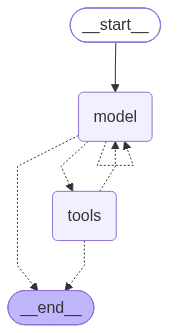

In [22]:
ideation_agent

### use it native (no graph)    

In [23]:
instruction = IDEATION_HUMAN_PROMPT.format(GAME_TITLE=GAME_TITLE)
agent_result = ideation_agent.invoke({
    "messages": [HumanMessage(content=instruction)]
})
ideas = agent_result["structured_response"].ideas

for idea in ideas:
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print(idea.style)
    print("-" * 100)

Eat the Universe Before It Eats You
Control a microscopic gravitational mouth accidentally released into space. Swallow debris smaller than yourself to grow, but orbit, ricochet, or flee from larger objects. Each meal alters your anatomy until you can consume moons, civilizations, and eventually the laws of physics.
The immediately understandable eat-and-grow loop is ideal for browser play, while mutation combinations and escalating cosmic hazards provide strong replay value. Its strange astronomical setting aligns closely with MABSTRUCT’s inventive sci-fi identity.
['Mouse or touch-controlled movement and suction', 'Objects carry mass, momentum, heat, and unusual side effects', 'Evolution choices such as split jaws, wormhole stomachs, and magnetic tongues', 'Procedurally assembled sectors for compact 10–15 minute runs', 'Bosses including a predatory sun and a planet that refuses to be eaten']
Physics arcade roguelite
Fast, colorful, surreal 2D space action with elastic animation and s

### now let us create a first graph

In [191]:
class GameDesignBrief(BaseModel):
    """
    The brief for the game.
    """
    game_title: str = Field(description="The title of the game")
    game_sub_title: str = Field(description="The sub title of the game")
    game_description: str = Field(description="A short description of the game in 2 to 5 sentences.")
    game_genre: str = Field(description="The genre of the game")
    game_theme: str = Field(description="The theme of the game")
    game_mood: str = Field(description="The mood of the game")
    game_style: str = Field(description="The style of the game")
    game_goal: str = Field(description="The goal of the game for the player")
    game_objective: str = Field(description="The objective of the game for the player")
    game_rules: str = Field(description="The rules of the game")
    game_controls: str = Field(description="The controls of the game")
    game_instructions: str = Field(description="The instructions of the game")
    game_mechanics: str = Field(description="The mechanics of the game")
    game_sound: str = Field(description="The sound of the game")
    game_art: str = Field(description="Describe the distinctive creative art and style of the game")
    hints_for_the_team: str = Field(description="Hints and additional information for the production and design team")


class GameDesignRecord(BaseModel):
    """Design brief linked to one ideation idea."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    brief: GameDesignBrief


class DesignJob(TypedDict):
    """Input passed to each design worker via Send."""
    game_title: str
    idea_id: str
    idea: GameIdea



In [192]:

class GameStudioState(TypedDict):
    """
    The development state of the game studio.
    """
    game_title: str
    game_ideation: GameIdeaList | None
    game_designs: Annotated[list[GameDesignRecord], operator.add]
    game_developments: Annotated[list[GameDevelopRecord], operator.add]
    #game_tests: Annotated[list[GameTestRecord], operator.add]
    game_html_path: str | None
    #test_result: dict | None      # optional aggregate; per-idea results in game_tests
    #deployment_url: str | None

initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_designs": [],
    "game_developments": [],
    #"game_tests": [],
    "game_html_path": None,
    #"test_result": None,
    #"deployment_url": None,
}

print(initial_state)

{'game_title': 'The Big Swallow', 'game_ideation': None, 'game_designs': [], 'game_developments': [], 'game_html_path': None}


In [193]:
def ideation_node(state: GameStudioState) -> dict:
    instruction = IDEATION_HUMAN_PROMPT.format(GAME_TITLE=state["game_title"])
    agent_result = ideation_agent.invoke({
        "messages": [HumanMessage(content=instruction)]
    })
    ideas = agent_result["structured_response"].ideas
    tagged_ideas = [
        idea.model_copy(update={"idea_id": str(uuid.uuid4())})
        for idea in ideas
    ]
    return {"game_ideation": GameIdeaList(ideas=tagged_ideas)}

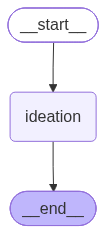

In [194]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_edge(START, "ideation")
builder.add_edge("ideation", END)
studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

In [195]:
result = studio.invoke(initial_state)
game_ideation = result["game_ideation"]


In [187]:
for idea in game_ideation.ideas:
    print(f"idea_id: {idea.idea_id}")
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print(idea.style)
    print("-" * 100)

idea_id: 5cff72be-2f9e-48ec-9f5f-825ebe4b2e7a
Eat the Cosmos Before It Eats You
Control a tiny gravitational mouth born at the edge of space. Swallow objects smaller than yourself—dust, drones, moons and eventually civilizations—while avoiding anything too large to digest. Each consumed object changes your mass, movement and anatomy, creating a different build every run.
The instantly understandable eat-to-grow loop suits short browser sessions, while roguelite mutations add replayability. Its escalating cosmic absurdity strongly reflects the studio’s inventive sci-fi identity and can deliver impressive spectacle with lightweight 2D technology.
['Mouse or touch-controlled gravitational movement', 'Objects with mass, momentum and dangerous digestive properties', 'Mutation choices such as split jaws, antimatter saliva and orbiting teeth', 'Risk-reward chain swallowing for score multipliers', 'Runs that escalate from a laboratory dish to galaxy-scale destruction', 'Daily seeded cosmos and

In [196]:
ideas = game_ideation.ideas
idea = ideas[0]

### a graph with two nodes (ideation & design)

#### prompts

In [197]:


DESIGN_SYSTEM_PROMPT = f"""
You are an experienced Game Designer for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
You have a strong background in browser games ideation and design.
You are known for your ability to create engaging, creative and fun browser games.
You create the best games design given the game idea and the title.
You create game design briefs for the production team to develop the game.

You create understandable games. The goals and achievments are clear to the player.
The rules and controls are clear to the player.
Instructions are clear and concise.
The game is fun and engaging.
The game is challenging and addictive.
The game is creative and innovative.
The game is unique and different.
The game is visually appealing.
The game is sound appealing.

"""

DESIGN_HUMAN_PROMPT = """
The task is to develop a game design brief for the following game:
The game title is {GAME_TITLE}.
The game idea is {GAME_IDEA}.
"""


#### the node

In [198]:
design_agent = create_agent(
    model=LLM_DESIGN_MODEL,
    system_prompt=DESIGN_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameDesignBrief,
)


def design_node(state: GameStudioState) -> dict:
    instruction = DESIGN_HUMAN_PROMPT.format(GAME_TITLE=state["game_title"], GAME_IDEA=state["game_ideation"].ideas[0])
    #idea_id = state["game_ideation"].ideas[0].idea_id
    agent_result = design_agent.invoke({
        "messages": [HumanMessage(content=instruction)]
    })
    return {
            "game_designs": [
                GameDesignRecord(
                    idea_id=state["game_ideation"].ideas[0].idea_id,
                    brief=agent_result["structured_response"],
                )
            ]
        }


#### the graph

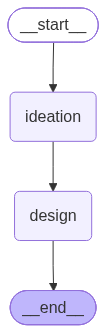

In [199]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
builder.add_node("design", design_node)

builder.add_edge(START, "ideation")
builder.add_edge("ideation", "design")
builder.add_edge("design", END)

studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

#### run

In [204]:
initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_designs": [],
    "game_developments": [],
    "game_tests": [],
    "game_html_path": None,
    "test_result": None,
    "deployment_url": None,
}

result = studio.invoke(initial_state)

print(f"Ideas: {len(result['game_ideation'].ideas)}")
print(f"Designs: {len(result['game_designs'])}")
print()

for record in result["game_designs"]:
    idea = next(i for i in result["game_ideation"].ideas if i.idea_id == record.idea_id)
    print(f"idea_id: {record.idea_id}")
    print("game_title: ", initial_state["game_title"])
    print(f"brief.sub_title: {record.brief.game_sub_title}")
    print(f"brief.genre: {record.brief.game_genre}")
    print(f"brief.description: {record.brief.game_description}")
    print(f"brief.theme: {record.brief.game_theme}")
    print(f"brief.style: {record.brief.game_style}")
    print(f"brief.mechanics: {record.brief.game_mechanics}")
    print(f"brief.mood: {record.brief.game_mood}")
    print(f"brief.sound: {record.brief.game_sound}")
    print(f"brief.art: {record.brief.game_art}")
    print(f"brief.hints_for_the_team: {record.brief.hints_for_the_team}")
    print("-" * 100)

brief = result["game_designs"][0].brief


Ideas: 5
Designs: 1

idea_id: 5777c429-29a4-4581-8697-9a4e66a40049
game_title:  The Big Swallow
brief.sub_title: Eat the Universe Before It Eats You
brief.genre: Physics-based arcade roguelite / score-chasing survival game
brief.description: The Big Swallow is a fast, physics-based arcade roguelite about a tiny gravitational mouth escaping a dying laboratory star. Drift through surreal cosmic biomes, swallow objects smaller than yourself, turn matter into bizarre mutations, and grow from a microscopic anomaly into an impossible universe-eating organism. Every short procedural run is a frantic race to become the predator before the surrounding cosmos becomes your predator.
brief.theme: Cosmic consumption, runaway evolution, laboratory catastrophe, and the absurdity of becoming a living gravitational singularity.
brief.style: Fast, colorful 2D cosmic surrealism. Objects have squishy elastic motion, expressive faces or silhouettes where appropriate, thick luminous outlines, exaggerated pa

### develop agent + develop_one node

Parallel develop workers mirror `design_one`: each builds `{notebook_dir}/dev-output/{game_title}/{idea_id}/index.html` via chunked HTML tools + Tier-0 validation.

#### structured types

In [206]:
class GameDevelopRecord(BaseModel):
    """Built HTML game linked to one design brief."""
    idea_id: str = Field(description="Matches GameIdea.idea_id")
    html_path: str = Field(description="Path to the written index.html")
    tier0_pass: bool = Field(description="Whether static Tier-0 validation passed")
    summary: str = Field(description="Developer confirmation: MVP vs deferred, validation notes")



#### prompts

In [207]:
DEVELOP_SYSTEM_PROMPT = f"""
You are an experienced Browser Game Developer for {MABSTRUCT_GAMESTUDIO_NAME}.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
Build a complete single-file HTML5 Canvas game (inline CSS + vanilla JS).
Architecture requirements:
- Exactly ONE inline <script> block for all JavaScript
- Separate update(dt, state) from render(state) where possible
- Multiply physics by dt (frame-rate independent)
- Implement MVP scope only; list deferred items honestly in your final answer
Writing (use write_game_html_part tool only — never paste HTML in chat):
1. part=start: <!DOCTYPE html> through opening <script> (no </script> or </html> yet)
2. part=js: raw JavaScript chunks only (repeat 4-8 times, each under 6000 chars)
3. part=end: final JS plus </script></body></html> — this writes the file
After part=end, call verify_game_html. If Tier-0 FAIL, rewrite from part=start.
Final answer: short confirmation with path, byte size, Tier-0 status, MVP vs deferred list.
"""

DEVELOP_HUMAN_PROMPT = """
Game title: {GAME_TITLE}
Idea id: {IDEA_ID}

Develop this browser game from the design brief below.

Sub-title: {game_sub_title}
Genre: {game_genre}
Theme: {game_theme}
Style: {game_style}
Description: {game_description}
Mechanics: {game_mechanics}
Mood: {game_mood}
Sound: {game_sound}
Art: {game_art}
Hints for the team: {hints_for_the_team}
"""

#### tools

In [208]:
from __future__ import annotations

from pathlib import Path
import re
import subprocess
import tempfile

NOTEBOOK_DIR = Path.cwd() / "mabstruct_studio" if (Path.cwd() / "mabstruct_studio" / "mabstruct_study.ipynb").exists() else Path.cwd()
STUDIO_OUTPUT_DIR = NOTEBOOK_DIR / "dev-output"
MAX_JS_CHUNK_CHARS = 6000
SCRIPT_BLOCK_RE = re.compile(
    r"<script(?![^>]*\bsrc=)[^>]*>(.*?)</script>",
    re.IGNORECASE | re.DOTALL,
)

def _game_html_path(game_title: str, idea_id: str) -> Path:
    return STUDIO_OUTPUT_DIR / game_title / idea_id / "index.html"


def run_static_validation(html_path: Path) -> dict:
    """Tier 0: single inline script block + node --check when available."""
    issues: list[str] = []
    checks: dict = {}

    if not html_path.exists():
        return {"pass": False, "issues": [f"missing file: {html_path}"], "checks": checks}

    html = html_path.read_text(encoding="utf-8")
    checks["bytes"] = len(html)
    script_blocks = [
        block.strip()
        for block in SCRIPT_BLOCK_RE.findall(html)
        if block.strip()
    ]
    checks["script_blocks"] = len(script_blocks)
    if len(script_blocks) != 1:
        issues.append(
            f"expected exactly 1 inline <script> block, found {len(script_blocks)}"
        )

    for index, block in enumerate(script_blocks):
        with tempfile.NamedTemporaryFile(
            mode="w", suffix=f"_{index}.js", delete=False, encoding="utf-8"
        ) as tmp:
            tmp.write(block)
            tmp_path = Path(tmp.name)
        try:
            proc = subprocess.run(
                ["node", "--check", str(tmp_path)],
                capture_output=True,
                text=True,
                timeout=10,
            )
            if proc.returncode != 0:
                message = (proc.stderr or proc.stdout or "parse failed").strip()
                issues.append(f"script block {index}: {message}")
        except FileNotFoundError:
            issues.append("node is not installed — cannot run JS parse check")
            break
        except subprocess.TimeoutExpired:
            issues.append(f"script block {index}: node --check timed out")
        finally:
            tmp_path.unlink(missing_ok=True)

    return {"pass": not issues, "issues": issues, "checks": checks}


def make_dev_tools(game_title: str, idea_id: str) -> list:
    """Per-idea HTML assembly tools (safe for parallel develop workers)."""
    buffer: list[str] = []

    @tool
    def write_game_html_part(content: str, part: str) -> str:
        """Assemble a single-file HTML game across start → js chunks → end."""
        nonlocal buffer

        if not content or not str(content).strip():
            return "Write rejected: content is empty."

        normalized = part.strip().lower()
        if normalized not in {"start", "js", "end"}:
            return 'Write rejected: part must be "start", "js", or "end".'

        if normalized in {"start", "js"} and len(content) > MAX_JS_CHUNK_CHARS:
            return (
                f"Write rejected: chunk too large ({len(content)} chars). "
                f"Split into pieces under {MAX_JS_CHUNK_CHARS} characters."
            )

        if normalized == "start":
            buffer.clear()
            lower = content.lower()
            if not lower.lstrip().startswith("<!doctype html"):
                return "Write rejected: start must begin with <!DOCTYPE html>"
            if "<script" not in lower:
                return "Write rejected: start must open exactly one <script> block"
            if "</script>" in lower or "</html>" in lower:
                return (
                    "Write rejected: start must NOT close </script> or </html>. "
                    "Use part=js for code and part=end for closing tags."
                )
            buffer.append(content)
            return f"Buffered start ({len(content)} chars). Next: part=js, then part=end."

        if normalized == "js":
            if not buffer:
                return "Write rejected: call part=start before part=js."
            lower = content.lower()
            for tag in ("<script", "</script>", "</html>", "<!doctype", "</body>", "<body"):
                if tag in lower:
                    return f"Write rejected: js part must be raw JavaScript only (found {tag})."
            buffer.append(content)
            total = sum(len(piece) for piece in buffer)
            return f"Buffered js ({len(content)} chars). Assembly total: {total} chars."

        if not buffer:
            return "Write rejected: call part=start before part=end."
        lower = content.lower()
        if "</script>" not in lower or "</html>" not in lower:
            return "Write rejected: end must include </script></body></html>."

        buffer.append(content)
        full = "".join(buffer)
        path = _game_html_path(game_title, idea_id)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(full, encoding="utf-8")
        buffer.clear()

        validation = run_static_validation(path)
        status = "PASS" if validation["pass"] else "FAIL"
        lines = [
            f"Wrote {path} ({len(full)} bytes)",
            f"Tier-0 validation: {status}",
        ]
        if validation["issues"]:
            lines.append("Issues: " + "; ".join(validation["issues"]))
        elif validation["pass"]:
            lines.append("Single inline script block parsed successfully.")
        if not validation["pass"]:
            lines.append("Fix issues and rewrite using part=start again.")
        return "\n".join(lines)

    @tool
    def verify_game_html() -> str:
        """Run Tier-0 validation on the current idea's index.html."""
        path = _game_html_path(game_title, idea_id)
        validation = run_static_validation(path)
        status = "PASS" if validation["pass"] else "FAIL"
        lines = [f"Tier-0 validation: {status}", f"File: {path}"]
        if validation["issues"]:
            lines.append("Issues:")
            lines.extend(f"- {issue}" for issue in validation["issues"])
        return "\n".join(lines)

    return [write_game_html_part, verify_game_html]


def _message_text(message) -> str:
    """Plain text from AIMessage; Opus may return thinking blocks as a list."""
    content = message.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts: list[str] = []
        for block in content:
            if isinstance(block, dict) and block.get("type") == "text":
                parts.append(block.get("text", ""))
            elif isinstance(block, str):
                parts.append(block)
        return "\n".join(part for part in parts if part)
    return str(content)


def _tool_names_from_messages(messages) -> list[str]:
    names: list[str] = []
    for msg in messages:
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            names.append(tc.get("name", "?"))
    return names




#### the develop node

In [209]:

def develop_node(state: GameStudioState) -> dict:
    game_title = state["game_title"]
    idea_id = state["game_ideation"][0].idea_id
    design = state["game_designs"][0]

    html_path = _game_html_path(game_title, idea_id)
    print(f"html_path: {html_path}")

    # A file left behind by an earlier run would otherwise be mistaken for this run's
    # output — and a half-written file from a crash would be mistaken for a build.
    html_path.parent.mkdir(parents=True, exist_ok=True)
    html_path.unlink(missing_ok=True)

    develop_agent = create_agent(
        model=LLM_DEVELOP_MODEL,
        system_prompt=DEVELOP_SYSTEM_PROMPT,
        tools=make_dev_tools(game_title, idea_id),
        middleware=DEVELOP_MIDDLEWARE,
    )

    instruction = DEVELOP_HUMAN_PROMPT.format(
        GAME_TITLE=game_title,
        IDEA_ID=idea_id,
        game_sub_title=design.game_sub_title,
        game_genre=design.game_genre,
        game_theme=design.game_theme,
        game_style=design.game_style,
        game_description=design.game_description,
        game_mechanics=design.game_mechanics,
        game_mood=design.game_mood,
        game_sound=design.game_sound,
        game_art=design.game_art,
        hints_for_the_team=design.hints_for_the_team,
    )

    agent_config = {"recursion_limit": DEVELOP_RECURSION_LIMIT}

    def _run(messages):
        """One agent run. A dead stream costs the turn, not the file already on disk."""
        try:
            return develop_agent.invoke({"messages": messages}, config=agent_config)
        except Exception as exc:
            print(f"develop invoke failed: {type(exc).__name__}: {exc}")
            return None

    def _validate() -> dict:
        return (
            run_static_validation(html_path)
            if html_path.exists()
            else {"pass": False, "issues": ["file not written"]}
        )

    agent_result = _run([HumanMessage(content=instruction)])
    validation = _validate()

    # One repair turn that continues the same conversation — never a second full build.
    if not validation["pass"] and agent_result is not None:
        if not html_path.exists():
            note = (
                "CRITICAL: index.html was NOT written. Use write_game_html_part only — "
                "part=start, then part=js (repeat 4-8 times), then part=end to write the "
                "file. Then call verify_game_html. Do not paste HTML in chat."
            )
        else:
            note = (
                "Tier-0 validation FAILED: " + "; ".join(validation["issues"]) + "\n"
                "Rewrite from part=start with that issue fixed, then call verify_game_html."
            )
        agent_result = _run(list(agent_result["messages"]) + [HumanMessage(content=note)])
        validation = _validate()

    messages = list(agent_result["messages"]) if agent_result else []
    summary = _message_text(messages[-1]) if messages else "develop agent produced no messages"
    if not validation["pass"]:
        summary = (
            f"{summary}\n\nTier-0 issues: {'; '.join(validation['issues'])}\n"
            f"Tools called: {_tool_names_from_messages(messages) or ['none']}"
        )

    return {
        "game_developments": [
            GameDevelopRecord(
                idea_id=idea_id,
                html_path=str(html_path.resolve()),
                tier0_pass=validation["pass"],
                summary=summary,
            )
        ]
    }


#### the singular dev graph (testing)

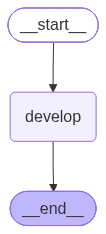

In [224]:
dev_builder = StateGraph(GameStudioState)

dev_builder.add_node("develop", develop_node)

#dev_builder.add_conditional_edges(START, fan_out_develop)
dev_builder.add_edge(START, "develop")
dev_builder.add_edge("develop", END)

dev_studio = dev_builder.compile()

display(Image(dev_studio.get_graph().draw_mermaid_png()))

In [225]:
ideas

[GameIdea(idea_id='a6fbec96-ebb5-4d4a-851b-372c67a026a5', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal 2D cosmic collage with elastic, liquid-like animation', reason='The immediately understandable “consume to grow” hook works especially well in a browser, while short runs, randomized upgrades, and physics-driven accidents create replayability. Its cosmic absurdity and experimental presentation closely match MABSTRUCT’s identity.', description='Control a tiny artificial singularity escaping from a laboratory. Swallow objects smaller than yourself, digest their properties, and grow from eating loose screws to consuming moons. Every meal changes your mass and gravitational pull, making movement increasingly dangerous as hunters, rival anomalies, and collapsing environments close in.', features=['Mouse-driven gravitational movement and slingshot navigation', 'Objects transfer traits such as magnetism, radioactivity, elasticity, or

In [220]:
dev_state = initial_state.copy()

dev_state["game_ideation"] = ideas
dev_state["game_designs"] = [brief]

print(dev_state)

{'game_title': 'The Big Swallow', 'game_ideation': [GameIdea(idea_id='a6fbec96-ebb5-4d4a-851b-372c67a026a5', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal 2D cosmic collage with elastic, liquid-like animation', reason='The immediately understandable “consume to grow” hook works especially well in a browser, while short runs, randomized upgrades, and physics-driven accidents create replayability. Its cosmic absurdity and experimental presentation closely match MABSTRUCT’s identity.', description='Control a tiny artificial singularity escaping from a laboratory. Swallow objects smaller than yourself, digest their properties, and grow from eating loose screws to consuming moons. Every meal changes your mass and gravitational pull, making movement increasingly dangerous as hunters, rival anomalies, and collapsing environments close in.', features=['Mouse-driven gravitational movement and slingshot navigation', 'Objects transfer trai

In [223]:
print(dev_state.get("game_ideation"))

[GameIdea(idea_id='a6fbec96-ebb5-4d4a-851b-372c67a026a5', sub_title='Eat the Universe Before It Eats You', genre='Physics-based action roguelite', style='Surreal 2D cosmic collage with elastic, liquid-like animation', reason='The immediately understandable “consume to grow” hook works especially well in a browser, while short runs, randomized upgrades, and physics-driven accidents create replayability. Its cosmic absurdity and experimental presentation closely match MABSTRUCT’s identity.', description='Control a tiny artificial singularity escaping from a laboratory. Swallow objects smaller than yourself, digest their properties, and grow from eating loose screws to consuming moons. Every meal changes your mass and gravitational pull, making movement increasingly dangerous as hunters, rival anomalies, and collapsing environments close in.', features=['Mouse-driven gravitational movement and slingshot navigation', 'Objects transfer traits such as magnetism, radioactivity, elasticity, or

In [222]:
devs = dev_state.get("game_developments")
devs


[]

In [216]:
dev_result = dev_studio.invoke(dev_state)

html_path: /Users/mab/dev/agents/pingmab-agents/mabstruct_studio/dev-output/The Big Swallow/a6fbec96-ebb5-4d4a-851b-372c67a026a5/index.html


KeyboardInterrupt: 

In [ ]:
dev_result

{'game_title': 'The Big Swallow',
 'game_ideation': [GameIdea(idea_id='TBS-01', sub_title='Eat the Universe Before It Eats You', genre='Physics arcade roguelite', style='Fast, colorful, surreal 2D space action with elastic animation and short replayable runs', reason='The immediately understandable eat-and-grow loop is ideal for browser play, while mutation combinations and escalating cosmic hazards provide strong replay value. Its strange astronomical setting aligns closely with MABSTRUCT’s inventive sci-fi identity.', description='Control a microscopic gravitational mouth accidentally released into space. Swallow debris smaller than yourself to grow, but orbit, ricochet, or flee from larger objects. Each meal alters your anatomy until you can consume moons, civilizations, and eventually the laws of physics.', features=['Mouse or touch-controlled movement and suction', 'Objects carry mass, momentum, heat, and unusual side effects', 'Evolution choices such as split jaws, wormhole stoma

### deploy

## Persisting to SQLite

`MemorySaver` keeps everything in memory, which vanishes when the program stops. For something durable we swap in the SQLite checkpointer, which writes to a database file. The same graph code now survives restarts. A file called `memory.db` appears next to this notebook, and you can delete it whenever you like.

In [ ]:
with SqliteSaver.from_conn_string("memory.db") as sql_memory:
    durable_graph = builder.compile(checkpointer=sql_memory)
    sql_config = {"configurable": {"thread_id": "conversation-2"}}
    durable_graph.invoke({"messages": [{"role": "user", "content": "Remember that my favorite color is orange."}]}, sql_config)
    reply = durable_graph.invoke({"messages": [{"role": "user", "content": "What is my favorite color?"}]}, sql_config)
    print(reply["messages"][-1].content)
    print(reply["spanish"])

## Adding a UI

Let's add a simple Gradio UI to bring this to life. The `chat` function kicks off one run of the graph per message, using a fixed `thread_id` so the conversation is remembered, and it shows the Spanish translation in italics beneath each reply.

In [ ]:
def chat(user_input: str, history):
    config = {"configurable": {"thread_id": "gradio-session4"}}
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    return f"{result['messages'][-1].content}\n\n*{result['spanish']}*"

gr.ChatInterface(chat).launch()

## Recap, and where we are heading

You have built graphs by hand: state with a reducer, nodes, edges, a conditional edge, a tool loop, a second LLM node, observability, memory in two flavors, and a way to inspect and replay the whole thing. This is the machinery that powers everything above it.

Tomorrow we reach Layer 3, our next step along the control to convenience spine. We will ask `create_agent` to build a graph exactly like the tool loop above, in a single line, and then we will render that graph and recognise it as our own.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Add a third tool to the graph, then ask the assistant a question that needs a search followed by a push notification and uses your tool, so the tool loop runs more than once. Then open the LangSmith dashboard, if you turned it on, and trace exactly which nodes ran and in what order.
            </span>
        </td>
    </tr>
</table>